# Hypothesis Testing

## Loading the Data 
As done in the EDA, we reload and merge the game, demo, score and sales data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from scipy import special
from os.path import join
import warnings
warnings.simplefilter('ignore')

base_games = pd.read_csv('base_games.csv')
demos = pd.read_csv('demos.csv')
scores = pd.read_csv('scores.csv')
sales = pd.read_csv('vgsales.csv')

In [2]:
def clean_title(t):
    if pd.isna(t): return np.nan
    text = str(t).lower()
    text = re.sub(r'\(.*?\)', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[-–:|]', ' ', text)
    text = re.sub(r'[^0-9a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

#cleaning the titles in every dataframe
base_games['base_name'] = base_games['name'].apply(clean_title)
scores['base_name'] = scores['name'].apply(clean_title)
sales['base_name'] = sales['Name'].apply(clean_title)

#converting each dataframe's selected columns to numeric values 
base_games['metacritic'] = pd.to_numeric(base_games['metacritic'], errors='coerce')
scores['metascore'] = pd.to_numeric(scores['metascore'], errors='coerce')
scores['userscore'] = pd.to_numeric(scores['userscore'], errors='coerce')

In [3]:
#merging each demo row with its corresponding full game data
games_with_demos = demos.merge(
    base_games,
    left_on='full_game_appid', 
    right_on='steam_appid',
    how='left',
    suffixes=('_demo','_full')
)

#if a match is found join the columns together
games_with_demos['base_name'] = games_with_demos['name_full'].apply(clean_title)



In [4]:
scores_pc = scores[scores['platform']=='PC'].copy()

demo_full_scores = games_with_demos.merge(
    scores_pc[['base_name','metascore','userscore']],
    on='base_name',
    how='left'
)

In [5]:
demo_full_sales = demo_full_scores.merge(
    sales[['base_name','Global_Sales']],
    on='base_name',
    how='left'
)

In [6]:
# show how many games gave demos
base_games['has_demo'] = base_games['steam_appid'].isin(demos['full_game_appid'])

## Hypothesis Test
In this section, we have two hypothesis in question:
1.	First Hypothesis
H0: Demo presence has no effect on full game scores.
Ha: Demo presence increases full game scores.

For **hypothesis 1**, we will be using **two tailed t-test** because there are two different groups(games with and without demos) and we have to evaluate if there is a difference between the means of the two groups.

2.	Second Hypothesis
H0: Demo popularity has no effect on full game sales.
Ha: Demo popularity increases the full game sales.

 Since direct data on **Demo Popularity** is not available, we measure it by metacritic scores. Higher-scoring games usually attract more engagement. 

For **Hypothesis 2**, we will also use **two tailed t-test** for the same reason as the one above.

In [8]:
# Build a merged table of Steam games + sales + demo flag (for hypothesis tests on sales)
games_all_sales = base_games.merge(
    sales[['base_name', 'Platform', 'Global_Sales']],
    on='base_name',
    how='left'
)


## Testing Hypothesis 1

Number of games with demos: 246
Number of games without demos: 3005

Metacritic scores data overview 

Demo games: 

mean = 73.97, std = 9.95

Non-demo games: 

mean = 73.90, std = 10.30

Two-sample t-test for scores
t-statistic: 0.101
p-value: 0.919

Fail to reject the null hypothesis: There is not enough evidence that demo presence changes Steam Metacritic scores.


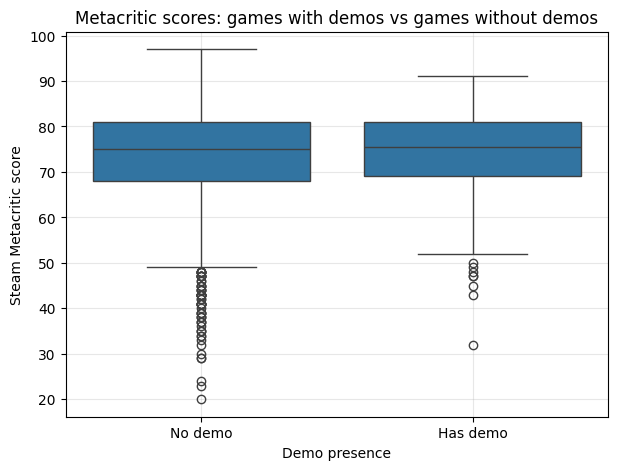

In [34]:
#seperate the two groups. If the game has a demo, it goes to demo_scores.
demo_scores = base_games.loc[base_games['has_demo'] == True, 'metacritic'].dropna()
no_demo_scores = base_games.loc[base_games['has_demo'] == False, 'metacritic'].dropna()

#print to show the content of the groups
print("Number of games with demos:", len(demo_scores))
print("Number of games without demos:", len(no_demo_scores))

#calculate the mean of demo and non-demo metascores
demo_mean= np.mean(demo_scores)
no_demo_mean = np.mean(no_demo_scores)

#calculate the sample standart deviation
std_demo = np.std(demo_scores, ddof=1)
std_no_demo = np.std(no_demo_scores, ddof=1)

print("\nMetacritic scores data overview \n")
print("Demo games: \n")
print(f"mean = {demo_mean:.2f}, std = {std_demo:.2f}\n")
print("Non-demo games: \n")
print(f"mean = {no_demo_mean:.2f}, std = {std_no_demo:.2f}")

#Two-tailed independent t-test
t_scores, p_scores = stats.ttest_ind( demo_scores,no_demo_scores,equal_var=False )
print("\nTwo-sample t-test for scores")
print(f"t-statistic: {t_scores:.3f}")
print(f"p-value: {p_scores:.3f}")

sig_level= 0.05
if p_scores < sig_level:
    print("\nReject the null hypothesis: There is evidence that demo presence is associated with different Steam Metacritic scores.")
else:
    print("\nFail to reject the null hypothesis: There is not enough evidence that demo presence changes Steam Metacritic scores.")

#boxplot of scores. created a new scores variable to seperate it from other scores dataframes.
scores_test = base_games[['metacritic', 'has_demo']].copy()
scores_test['demo_label'] = scores_test['has_demo'].map({True: 'Has demo', False: 'No demo'})

plt.figure(figsize=(7, 5))
sns.boxplot(data=scores_test, x='demo_label', y='metacritic')
plt.xlabel("Demo presence")
plt.ylabel("Steam Metacritic score")
plt.title("Metacritic scores: games with demos vs games without demos")
plt.grid(alpha=0.3)
plt.show()


## Testing Hypothesis 2

Number of games with demos (sales): 703
Number of games without demos (sales): 11800

Global sales data overview

Demo games: 

mean = 0.784, std = 0.453

Non-demo games: 

mean = 0.825, std = 0.724

Two-sample t-test for sales
t-statistic: -2.181
p-value: 0.029

Reject the null hypothesis: There is evidence that demo presence is associated with different global sales.


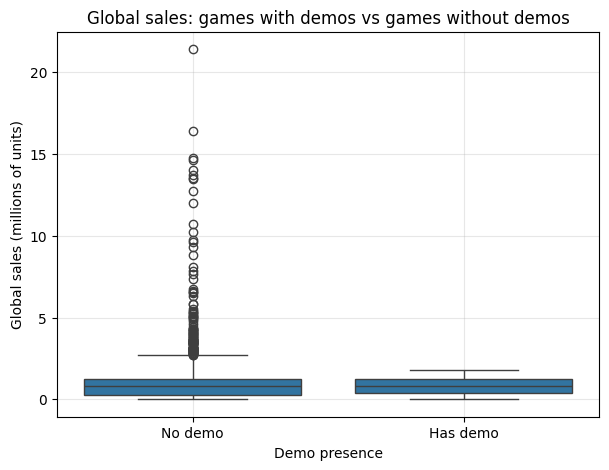

In [37]:

#seperate the two groups. if the game has a demo, it goes to demo_sales,
demo_sales = games_all_sales.loc[games_all_sales['has_demo'] == True, 'Global_Sales'].dropna()
no_demo_sales = games_all_sales.loc[games_all_sales['has_demo'] == False, 'Global_Sales'].dropna()

print("Number of games with demos (sales):", len(demo_sales))
print("Number of games without demos (sales):", len(no_demo_sales))

#calculate the mean of demo and non-demo sales
demo_mean_sales = np.mean(demo_sales)
no_demo_mean_sales= np.mean(no_demo_sales)
demo_std_sales = np.std(demo_sales, ddof=1)
no_demo_std_sales= np.std(no_demo_sales, ddof=1)

print("\nGlobal sales data overview\n")
print("Demo games: \n")
print(f"mean = {demo_mean_sales:.3f}, std = {demo_std_sales:.3f}\n")
print("Non-demo games: \n")
print(f"mean = {no_demo_mean_sales:.3f}, std = {no_demo_std_sales:.3f}")


#Two-tailed independent t-test
t_sales, p_sales = stats.ttest_ind(demo_sales, no_demo_sales, equal_var=False)

print("\nTwo-sample t-test for sales")
print(f"t-statistic: {t_sales:.3f}")
print(f"p-value: {p_sales:.3f}")

sig_level= 0.05
if p_sales < sig_level:
    print("\nReject the null hypothesis: There is evidence that demo presence is associated with different global sales.")
else:
    print("\nFail to reject the null hypothesis: There is not enough evidence that demo presence changes global sales.")

#boxplot of sales for demo vs non-demo games
sales_test= games_all_sales[['Global_Sales', 'has_demo']].copy()
sales_test['demo_label'] = sales_test['has_demo'].map({True: 'Has demo', False: 'No demo'})

plt.figure(figsize=(7, 5))
sns.boxplot(data=sales_test, x='demo_label', y='Global_Sales')
plt.xlabel("Demo presence")
plt.ylabel("Global sales (millions of units)")
plt.title("Global sales: games with demos vs games without demos")
plt.grid(alpha=0.3)
plt.show()
